# Intro to NNs: MNIST

Sam Foreman [](https://orcid.org/0000-0002-9981-0876)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
Marieme Ngom
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/marieme-ngom>))  
Huihuo Zheng
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/huihuo-zheng>))  
Bethany Lusch [](https://orcid.org/0000-0002-9521-9990)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/bethany-lusch>))  
Taylor Childers [](https://orcid.org/0000-0002-0492-613X)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/taylor-childers>))  
2025-07-17

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/01-neural-networks/1-mnist/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/docs/01-neural-networks/1-mnist/README.md)

> **Note**
>
> Content for this tutorial has been modified from content originally
> written by:
>
> Marieme Ngom, Bethany Lusch, Asad Khan, Prasanna Balaprakash, Taylor
> Childers, Corey Adams, Kyle Felker, and Tanwi Mallick

This tutorial will serve as a gentle introduction to neural networks and
deep learning through a hands-on classification problem using the MNIST
dataset.

In particular, we will introduce neural networks and how to train and
improve their learning capabilities. We will use the PyTorch Python
library.

The [MNIST dataset](http://yann.lecun.com/exdb/mnist/) contains
thousands of examples of handwritten numbers, with each digit labeled
0-9.

<figure id="fig-mnist-task">
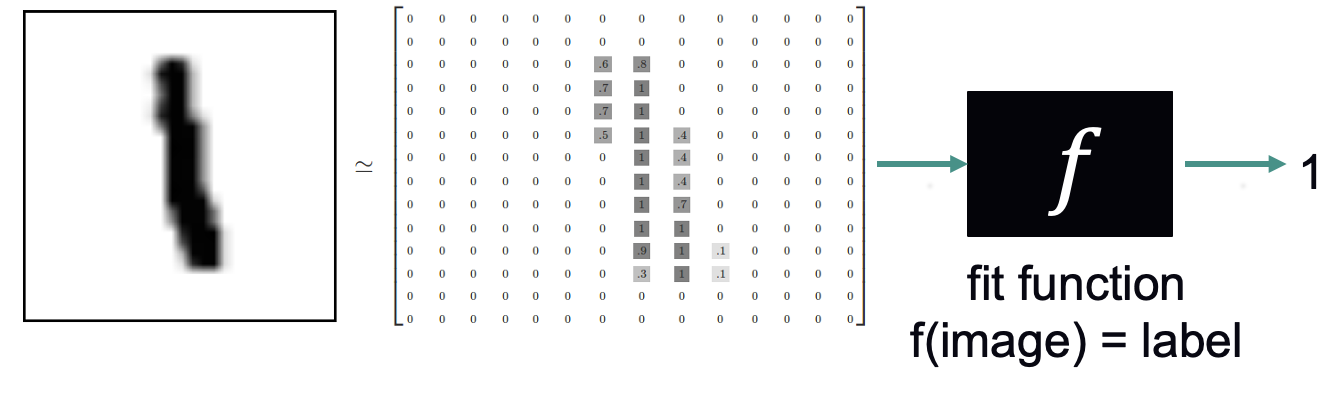
<figcaption>Figure 1: MNIST sample</figcaption>
</figure>

In [1]:
import ambivalent

import matplotlib.pyplot as plt
import seaborn as sns

import ezpz
# console = ezpz.log.get_console()
logger = ezpz.get_logger('mnist')

plt.style.use(ambivalent.STYLES['ambivalent'])
sns.set_context("notebook")
plt.rcParams["figure.figsize"] = [6.4, 4.8]

import plotly.graph_objects as go
from bootcamp.plotly_theme import apply_theme, COLORS
apply_theme()   # house style for interactive charts (loss/accuracy curves)

'ambivalent'

In [2]:
# %matplotlib inline

import torch
import torchvision
from torch import nn

import numpy 
import matplotlib.pyplot as plt
import time

## The MNIST dataset

We will now download the dataset that contains handwritten digits. MNIST
is a popular dataset, so we can download it via the PyTorch library.

Note:

- `x` is for the inputs (images of handwritten digits)
- `y` is for the labels or outputs (digits 0-9)
- We are given “training” and “test” datasets.
  - Training datasets are used to fit the model.
  - Test datasets are saved until the end, when we are satisfied with
    our model, to estimate how well our model generalizes to new data.

Note that downloading it the first time might take some time.

The data is split as follows:

- 60,000 training examples, 10,000 test examples
- inputs: 1 x 28 x 28 pixels
- outputs (labels): one integer per example

In [3]:
training_data = torchvision.datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor()
)

test_data = torchvision.datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor()
)

In [4]:
train_size = int(0.8 * len(training_data))  # 80% for training
val_size = len(training_data) - train_size  # Remaining 20% for validation
training_data, validation_data = torch.utils.data.random_split(
    training_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(55)
)

In [5]:
logger.info(
    " ".join([
        f"MNIST data loaded:",
        f"train={len(training_data)} examples",
        f"validation={len(validation_data)} examples",
        f"test={len(test_data)} examples",
        f"input shape={training_data[0][0].shape}" 
    ])
)
# logger.info(f'Input shape', training_data[0][0].shape)

Let’s take a closer look. Here are the first 10 training digits:

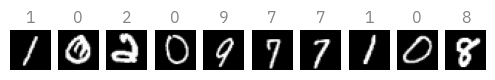

In [6]:
pltsize=1
# plt.figure(figsize=(10*pltsize, pltsize))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.axis('off')
    # x, y = training_data[i]
    # plt.imshow(x.reshape(28, 28), cmap="gray")
    # x[0] is the image, x[1] is the label
    plt.imshow(
        numpy.reshape(
            training_data[i][0],
            (28, 28)
        ),
        cmap="gray"
    )
    plt.title(f"{training_data[i][1]}") 

## Generalities:

To train our classifier, we need (besides the data):

- A model that depend on parameters $\mathbf{\theta}$. Here we are going
  to use neural networks.
- A loss function $J(\mathbf{\theta})$ to measure the capabilities of
  the model.
- An optimization method.

## Linear Model

Let’s begin with a simple linear model: linear regression, like last
week.

We add one complication: each example is a vector (flattened image), so
the “slope” multiplication becomes a dot product. If the target output
is a vector as well, then the multiplication becomes matrix
multiplication.

Note, like before, we consider multiple examples at once, adding another
dimension to the input.

<figure id="fig-linear-svg">
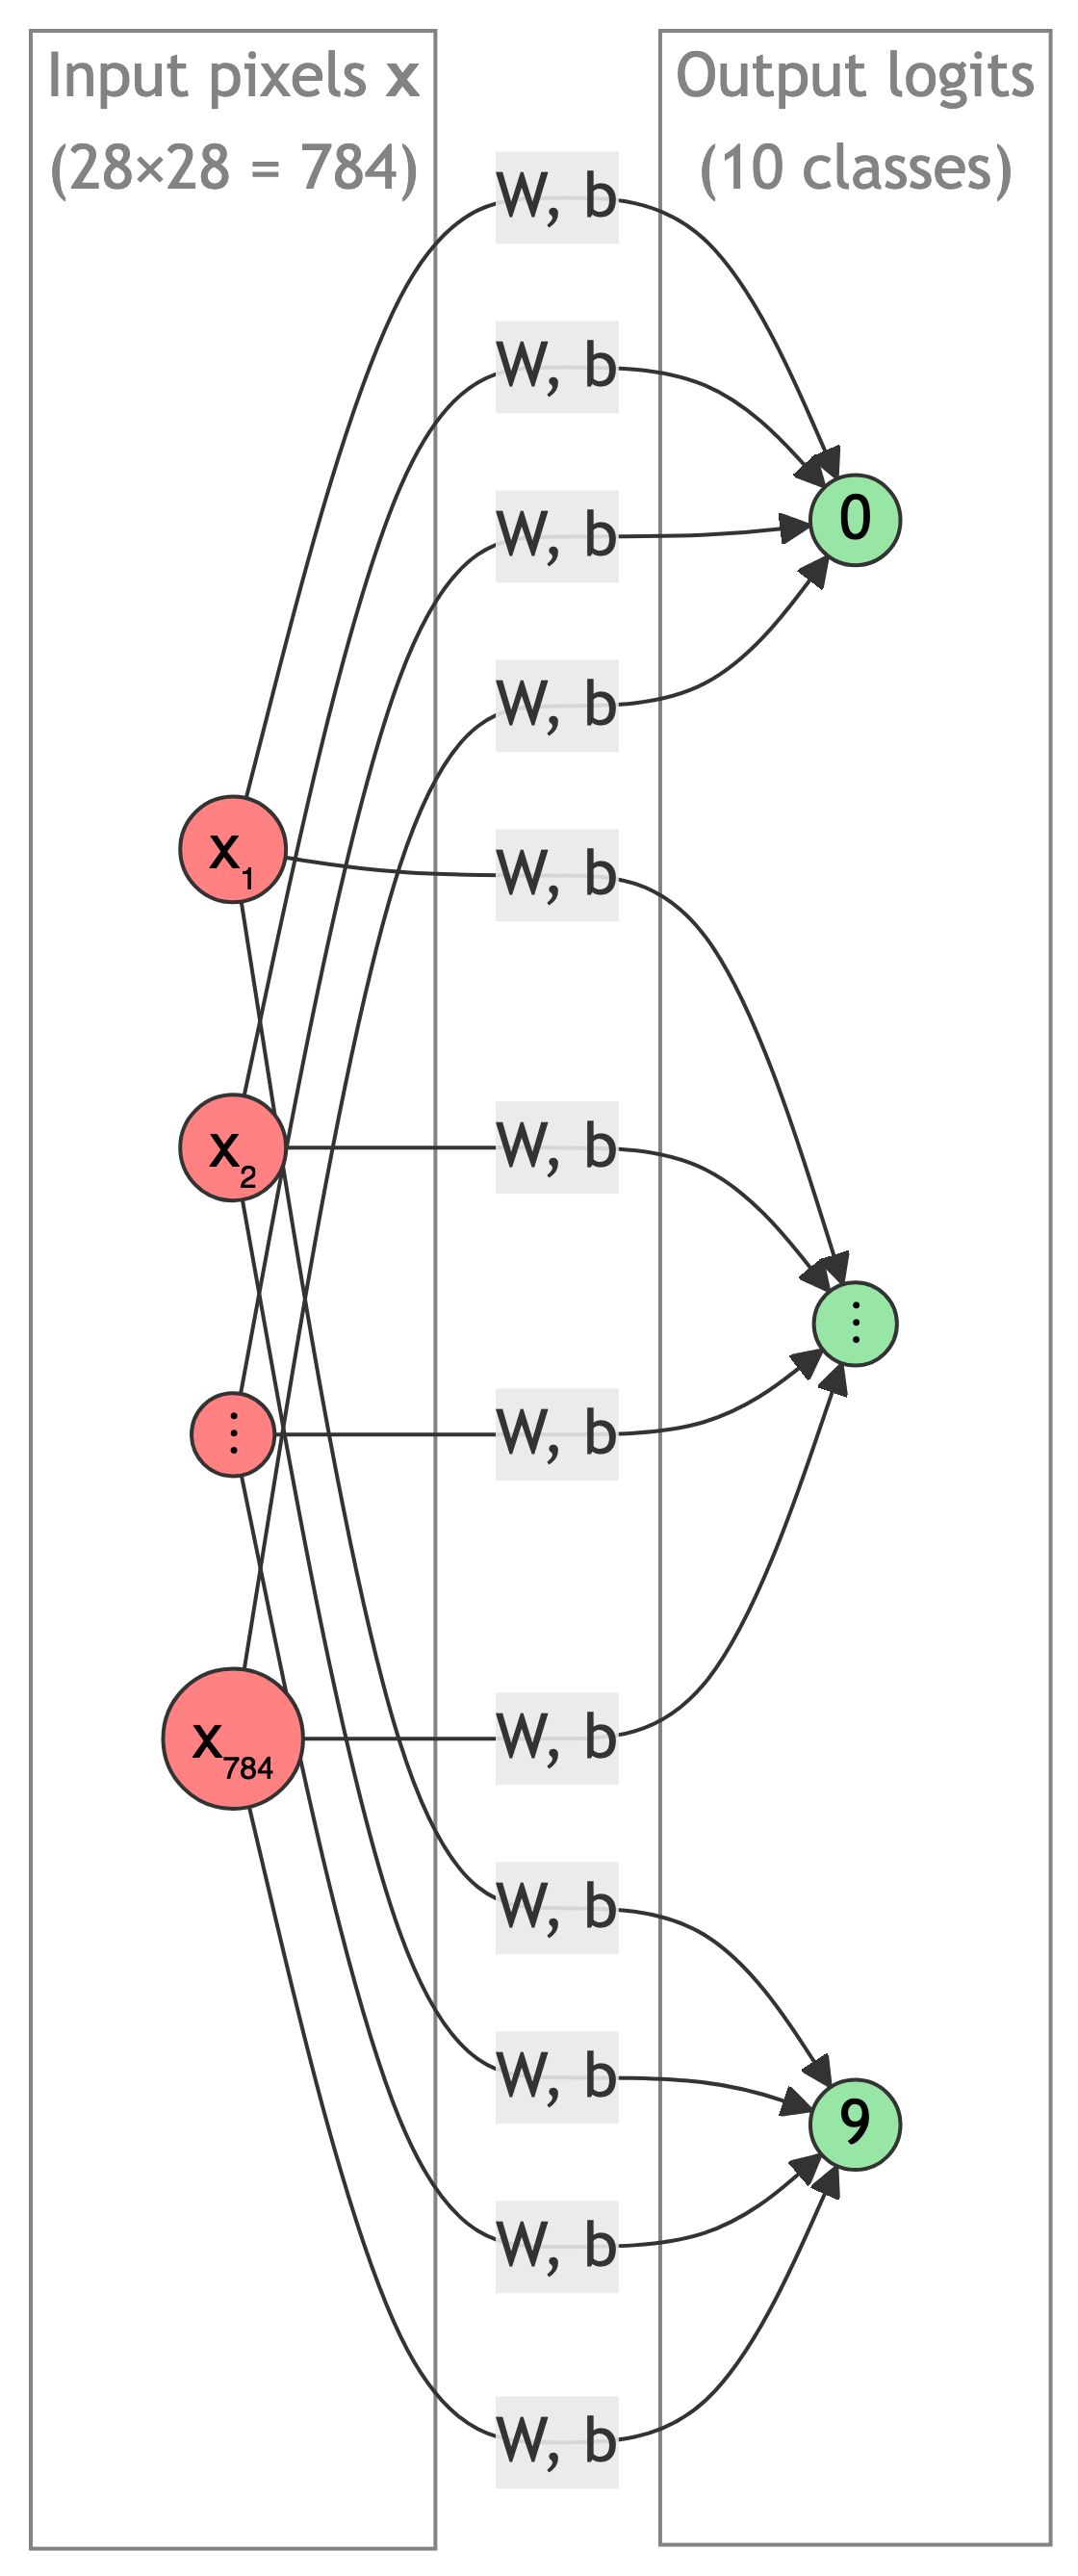
<figcaption>Figure 2: A fully-connected linear layer: every input pixel
connects to every output class via <span
class="math inline"><strong>x</strong><strong>W</strong> + <strong>b</strong></span>.</figcaption>
</figure>

The linear layers in PyTorch perform a basic $xW + b$.

These “fully connected” layers connect each input to each output with
some weight parameter.

We wouldn’t expect a simple linear model $f(x) = xW+b$ directly
outputting the class label and minimizing mean squared error to work
well - the model would output labels like 3.55 and 2.11 instead of
skipping to integers.

We now need:

- A loss function $J(\theta)$ where $\theta$ is the list of parameters
  (here W and b). Last week, we used mean squared error (MSE), but this
  week let’s make two changes that make more sense for classification:
  - Change the output to be a length-10 vector of class probabilities (0
    to 1, adding to 1).
  - Cross entropy as the loss function, which is typical for
    classification. You can read more
    [here](https://gombru.github.io/2018/05/23/cross_entropy_loss/).
- An optimization method or optimizer such as the stochastic gradient
  descent (sgd) method, the Adam optimizer, RMSprop, Adagrad etc. Let’s
  start with stochastic gradient descent (sgd), like last week. For far
  more information about more advanced optimizers than basic SGD, with
  some cool animations, see
  <https://ruder.io/optimizing-gradient-descent/> or
  <https://distill.pub/2017/momentum/>.
- A learning rate. As we learned last week, the learning rate controls
  how far we move during each step.

In [7]:
class LinearClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        # First, we need to convert the input image to a vector by using 
        # nn.Flatten(). For MNIST, it means the second dimension 28*28 becomes 784.
        self.flatten = nn.Flatten()
        # Here, we add a fully connected ("dense") layer that has 28 x 28 = 784 input nodes 
        #(one for each pixel in the input image) and 10 output nodes (for probabilities of each class).
        self.layer_1 = nn.Linear(28*28, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.layer_1(x)
        return x

In [8]:
linear_model = LinearClassifier()
logger.info(linear_model)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(linear_model.parameters(), lr=0.05)

## Learning

Now we are ready to train our first model.

A training step is comprised of:

- A forward pass: the input is passed through the network
- Backpropagation: A backward pass to compute the gradient
  $\frac{\partial J}{\partial \mathbf{W}}$ of the loss function with
  respect to the parameters of the network.
- Weight updates
  $\mathbf{W} = \mathbf{W} - \alpha \frac{\partial J}{\partial \mathbf{W}}$
  where $\alpha$ is the learning rate.

How many steps do we take?

- The batch size corresponds to the number of training examples in one
  pass (forward + backward).
  - A smaller batch size allows the model to learn from individual
    examples but takes longer to train.
  - A larger batch size requires fewer steps but may result in the model
    not capturing the nuances in the data.
- The higher the batch size, the more memory you will require.
- An epoch means one pass through the whole training data (looping over
  the batches). Using few epochs can lead to underfitting and using too
  many can lead to overfitting.
- The choice of batch size and learning rate are important for
  performance, generalization and accuracy in deep learning.

In [9]:
batch_size = 128

# The dataloader makes our dataset iterable 
train_dataloader = torch.utils.data.DataLoader(training_data, batch_size=batch_size)
val_dataloader = torch.utils.data.DataLoader(validation_data, batch_size=batch_size)

In [10]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # forward pass
        pred = model(X)
        loss = loss_fn(pred, y)
        # backward pass calculates gradients
        loss.backward()
        # take one step with these gradients
        optimizer.step()
        # resets the gradients 
        optimizer.zero_grad()

In [11]:
def evaluate(dataloader, model, loss_fn):
    # Set the model to evaluation mode - some NN pieces behave differently during training
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    loss, correct = 0, 0

    # We can save computation and memory by not calculating gradients here - we aren't optimizing 
    with torch.no_grad():
        # loop over all of the batches
        for X, y in dataloader:
            pred = model(X)
            loss += loss_fn(pred, y).item()
            # how many are correct in this batch? Tracking for accuracy 
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    loss /= num_batches
    correct /= size

    accuracy = 100*correct
    return accuracy, loss

In [12]:
%%time

epochs = 5
train_acc_all = []
val_acc_all = []
for j in range(epochs):
    train_one_epoch(train_dataloader, linear_model, loss_fn, optimizer)

    # checking on the training loss and accuracy once per epoch
    acc, loss = evaluate(train_dataloader, linear_model, loss_fn)
    train_acc_all.append(acc)
    logger.info(f"Epoch {j}: training loss: {loss}, accuracy: {acc}")

    # checking on the validation loss and accuracy once per epoch
    val_acc, val_loss = evaluate(val_dataloader, linear_model, loss_fn)
    val_acc_all.append(val_acc)
    logger.info(f"Epoch {j}: val. loss: {val_loss}, val. accuracy: {val_acc}")

In [13]:
fig = go.Figure()
fig.add_scatter(x=list(range(epochs)), y=train_acc_all, mode="lines+markers",
                name="Training Acc.", line=dict(color=COLORS["blue"]))
fig.add_scatter(x=list(range(epochs)), y=val_acc_all, mode="lines+markers",
                name="Validation Acc.", line=dict(color=COLORS["orange"]))
fig.update_layout(xaxis_title="Epoch #", yaxis_title="Accuracy", height=400)
fig.show()

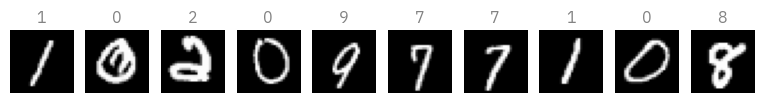

In [14]:
# Visualize how the model is doing on the first 10 examples
pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))
linear_model.eval()
batch = next(iter(train_dataloader))
predictions = linear_model(batch[0])

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.axis('off')
    plt.imshow(batch[0][i,0,:,:], cmap="gray")
    plt.title('%d' % predictions[i,:].argmax())

Exercise: How can you improve the accuracy? Some things you might
consider: increasing the number of epochs, changing the learning rate,
etc.

## Prediction

Let’s see how our model generalizes to the unseen test data.

In [15]:
#For HW: cell to change batch size
#create dataloader for test data
# The dataloader makes our dataset iterable

batch_size_test = 256 
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size_test)

In [16]:
acc_test, loss_test = evaluate(test_dataloader, linear_model, loss_fn)
logger.info(f"Test loss: {loss_test}, test accuracy: {acc_test}")
# logger.info("Test loss: %.4f, test accuracy: %.2f%%" % (loss_test, acc_test))

We can now take a closer look at the results.

Let’s define a helper function to show the failure cases of our
classifier.

In [17]:
def show_failures(model, dataloader, maxtoshow=10):
    model.eval()
    batch = next(iter(dataloader))
    predictions = model(batch[0])

    rounded = predictions.argmax(1)
    errors = rounded!=batch[1]
    logger.info(
        f"Showing max {maxtoshow} first failures."
    )
    logger.info("The predicted class is shown first and the correct class in parentheses.")
    ii = 0
    plt.figure(figsize=(maxtoshow, 1))
    for i in range(batch[0].shape[0]):
        if ii>=maxtoshow:
            break
        if errors[i]:
            plt.subplot(1, maxtoshow, ii+1)
            plt.axis('off')
            plt.imshow(batch[0][i,0,:,:], cmap="gray")
            plt.title("%d (%d)" % (rounded[i], batch[1][i]))
            ii = ii + 1

Here are the first 10 images from the test data that this small model
classified to a wrong class:

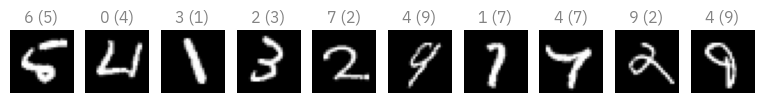

In [18]:
show_failures(linear_model, test_dataloader)

## Multilayer Model

Our linear model isn’t enough for high accuracy on this dataset. To
improve the model, we often need to add more layers and nonlinearities.

<figure id="fig-shallow-nn">
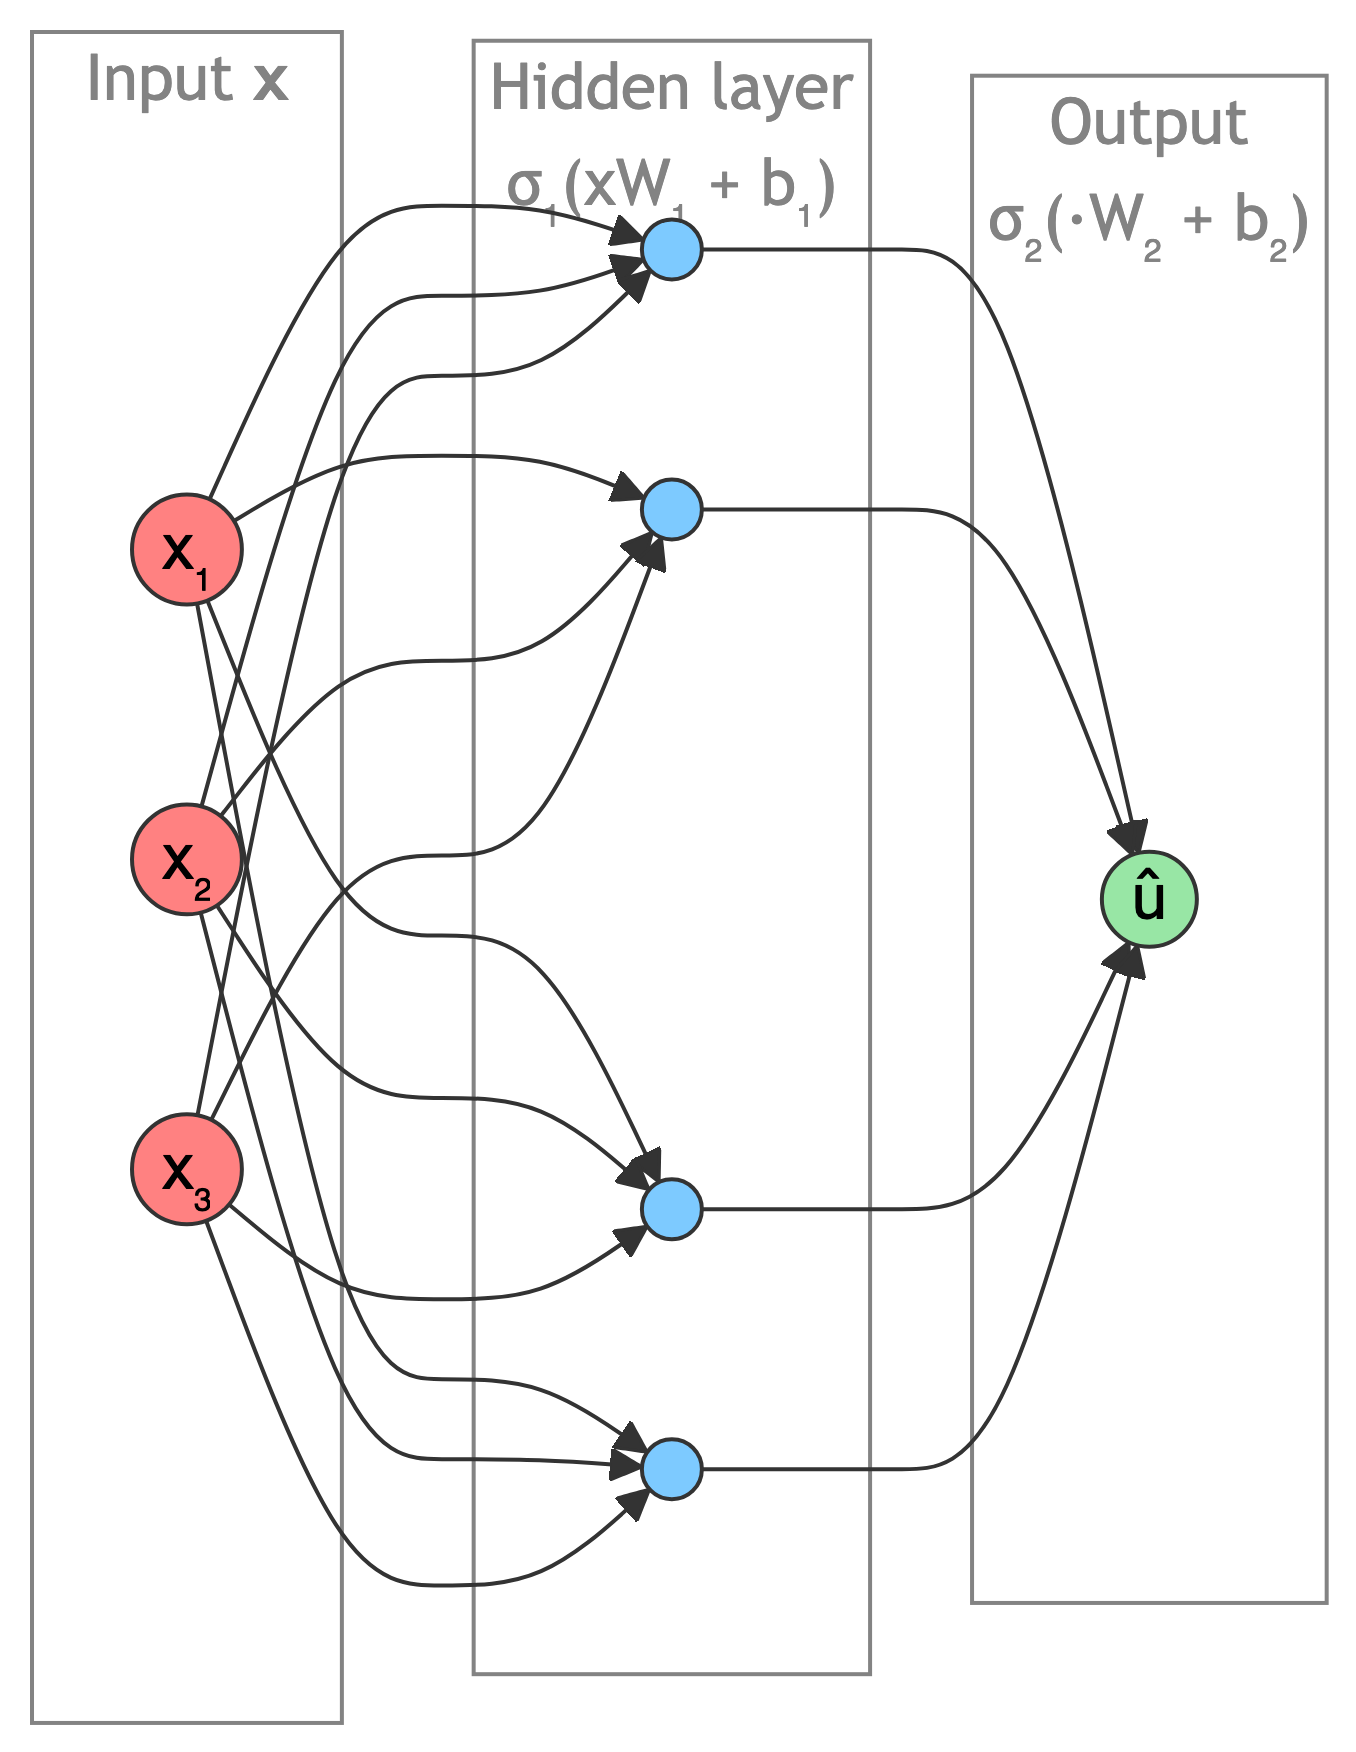
<figcaption>Figure 3: A shallow (single-hidden-layer) neural
network.</figcaption>
</figure>

The output of this NN can be written as

$$\begin{equation}
  \hat{u}(x) = \sigma_2(\sigma_1(\mathbf{x}\mathbf{W}_1 + \mathbf{b}_1)\mathbf{W}_2 + \mathbf{b}_2),
\end{equation}$$

where $\mathbf{x}$ is the input, $\mathbf{W}_j$ are the weights of the
neural network, $\sigma_j$ the (nonlinear) activation functions, and
$\mathbf{b}_j$ its biases.

A few of the most common activation functions, plotted over
$x \in [-5, 5]$:

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 400)

def sigmoid(x): return 1 / (1 + np.exp(-x))

activations = {
    "Identity":    x,
    "Sigmoid":     sigmoid(x),
    "Tanh":        np.tanh(x),
    "ReLU":        np.maximum(0, x),
    "Leaky ReLU":  np.where(x > 0, x, 0.1 * x),
    "PReLU (a=.25)": np.where(x > 0, x, 0.25 * x),
    "ELU":         np.where(x > 0, x, np.exp(x) - 1),
    "SELU":        1.0507 * np.where(x > 0, x, 1.6733 * (np.exp(x) - 1)),
    "Softplus":    np.log1p(np.exp(x)),
    "GELU":        0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3))),
    "SiLU / Swish": x * sigmoid(x),
    "Mish":        x * np.tanh(np.log1p(np.exp(x))),
}

fig, axes = plt.subplots(3, 4, figsize=(12, 8), sharex=True, sharey=True)
for ax, (name, y) in zip(axes.flat, activations.items()):
    ax.plot(x, y, color="#7DCAFF", linewidth=2)
    ax.axhline(0, color="#838383", linewidth=0.7, zorder=0)
    ax.axvline(0, color="#838383", linewidth=0.7, zorder=0)
    ax.set_title(name, fontsize=11)
    ax.set_xlim(-5, 5)      # curves fill the full axis (no ambivalent x-margin)
    ax.set_ylim(-3, 5)      # symmetric-ish range that contains every curve
    ax.set_xticks([-5, 0, 5])
    ax.set_yticks([-2, 0, 2, 4])
    ax.grid(alpha=0.15)
fig.suptitle("Activation functions", fontsize=14)
fig.tight_layout()
plt.show()

The **activation function** introduces the nonlinearity that lets the
network learn complex tasks. Desirable properties include being
differentiable, (mostly) monotonic, and well-behaved gradients. `ReLU`
and its variants (`Leaky ReLU`, `ELU`, `GELU`, `SiLU`) dominate modern
deep networks because they avoid the vanishing-gradient problem that
plagues the saturating `Sigmoid`/`Tanh`.

Stacking several hidden layers gives a **deep** neural network — each
layer transforms the previous layer’s output, letting the model build up
increasingly abstract representations:

<figure id="fig-nn-annotated">
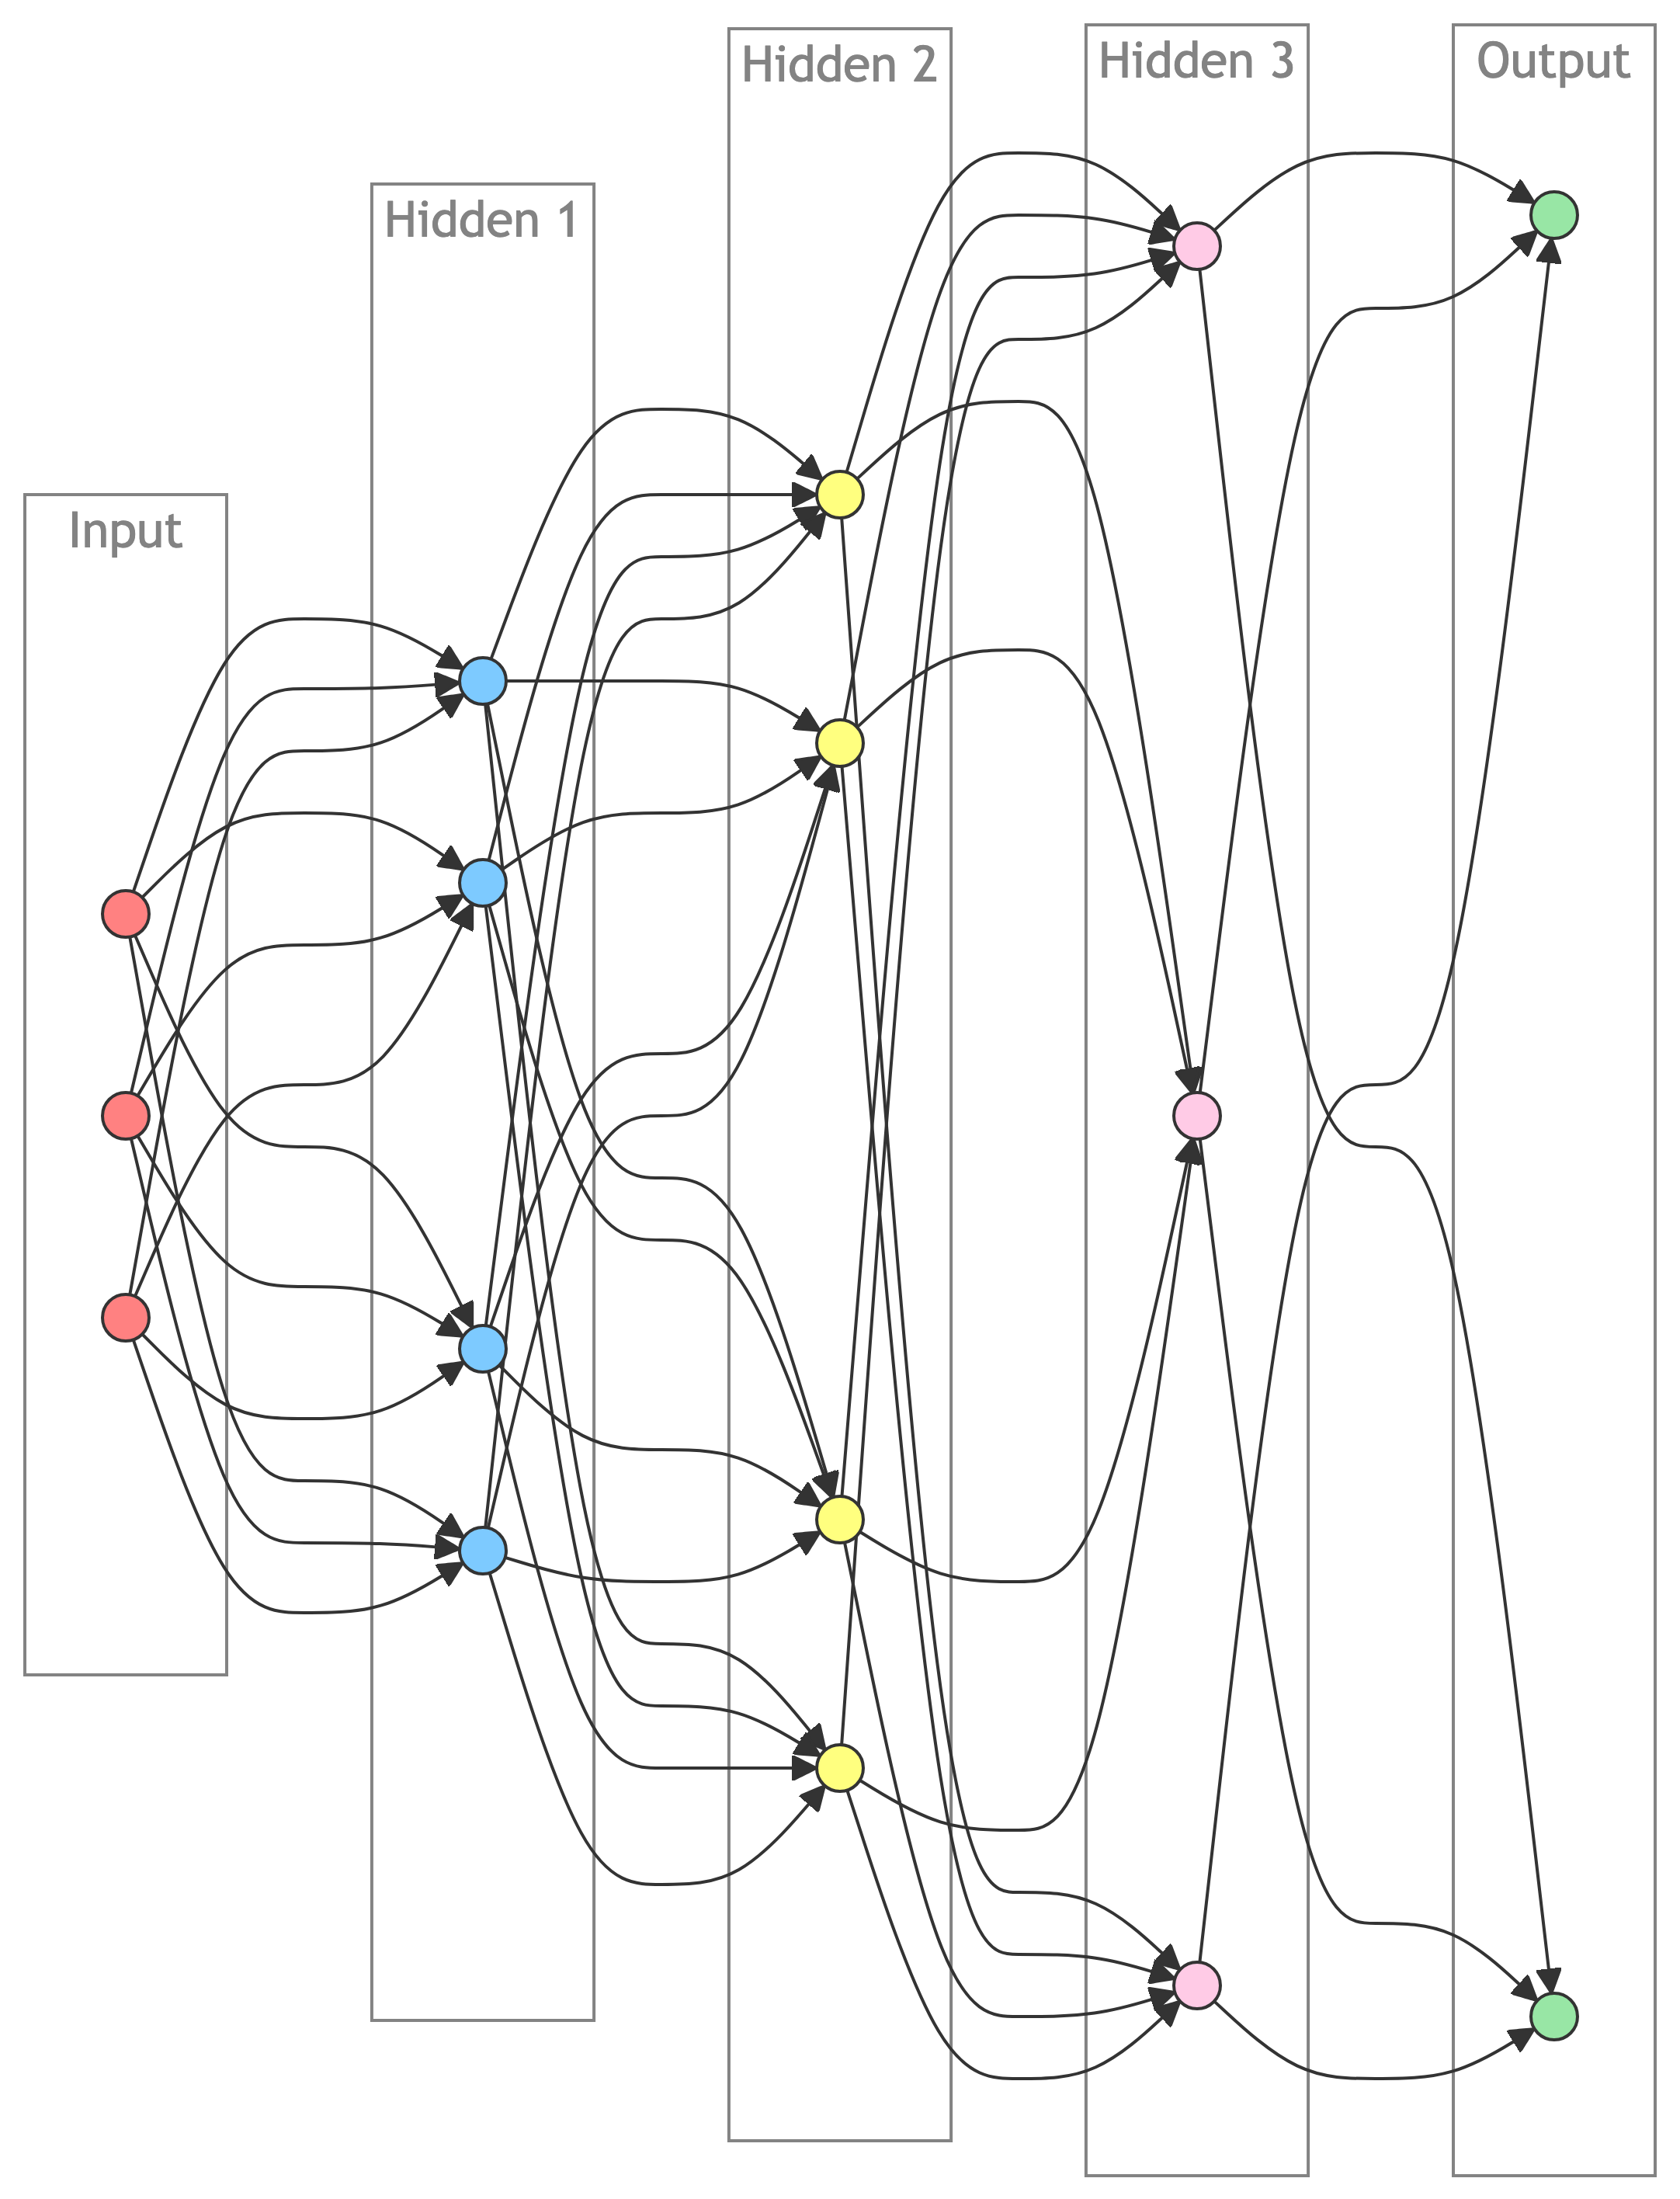
<figcaption>Figure 5: A deep neural network with several hidden
layers.</figcaption>
</figure>

## Important things to know

Deep Neural networks can be overly flexible/complicated and “overfit”
your data, just like fitting overly complicated polynomials. Let’s see
this directly: we generate noisy samples from a smooth **true function**
(a cosine), then fit polynomials of increasing degree and watch what
happens.

In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from plotly.subplots import make_subplots

def true_fn(x):
    return np.cos(1.5 * np.pi * x)

rng = np.random.default_rng(0)
n = 30
x_train = np.sort(rng.uniform(0, 1, n))
y_train = true_fn(x_train) + rng.normal(0, 0.1, n)   # noisy observations
x_plot = np.linspace(0, 1, 200)

degrees = [1, 4, 15]
labels = ["Underfitting (high bias)", "Balanced", "Overfitting (high variance)"]
fig = make_subplots(rows=1, cols=3, subplot_titles=[
    f"{lab}<br>degree {d}" for lab, d in zip(labels, degrees)])

for col, deg in enumerate(degrees, start=1):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(x_train[:, None], y_train)
    # 10-fold CV MSE, to quantify how badly each generalizes
    mse = -cross_val_score(model, x_train[:, None], y_train,
                           scoring="neg_mean_squared_error", cv=10).mean()
    y_model = model.predict(x_plot[:, None])
    show = (col == 1)   # one shared legend
    fig.add_scatter(x=x_plot, y=true_fn(x_plot), mode="lines", name="true function",
                    line=dict(color=COLORS["orange"], width=2),
                    legendgroup="t", showlegend=show, row=1, col=col)
    fig.add_scatter(x=x_plot, y=y_model, mode="lines", name="model",
                    line=dict(color=COLORS["blue"], width=2),
                    legendgroup="m", showlegend=show, row=1, col=col)
    fig.add_scatter(x=x_train, y=y_train, mode="markers", name="samples",
                    marker=dict(color=COLORS["blue"], size=6, opacity=0.6),
                    legendgroup="s", showlegend=show, row=1, col=col)
    fig.update_xaxes(title_text=f"MSE ≈ {mse:.2g}", row=1, col=col,
                     showticklabels=False)
    fig.update_yaxes(range=[-1.8, 1.8], showticklabels=False, row=1, col=col)

fig.update_layout(height=360, margin=dict(t=60),
                  legend=dict(orientation="h", y=-0.08))
fig.show()

The **degree-1** line is too simple to follow the curve (**underfitting
/ high bias**); the **degree-15** polynomial contorts itself to hit
every noisy point and swings wildly between them (**overfitting / high
variance**); **degree 4** captures the real shape without chasing the
noise. The cross-validated MSE (below each panel) is lowest for the
balanced model — that’s the sweet spot we want.

Vizualization wrt to the accuracy and loss (Image source:
[Baeldung](https://www.baeldung.com/cs/ml-underfitting-overfitting)):

<figure id="fig-acc-under-over">
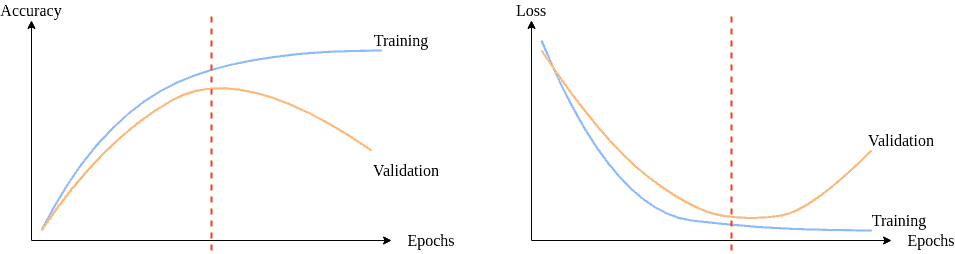
<figcaption>Figure 6: Visualization of accuracy and loss</figcaption>
</figure>

To improve the generalization of our model on previously unseen data, we
employ a technique known as regularization, which constrains our
optimization problem in order to discourage complex models.

- Dropout is the commonly used regularization technique. The Dropout
  layer randomly sets input units to 0 with a frequency of rate at each
  step during training time, which helps prevent overfitting.
- Penalizing the loss function by adding a term such as
  $\lambda ||\mathbf{W}||^2$ is alsp a commonly used regularization
  technique. This helps “control” the magnitude of the weights of the
  network.

Vanishing gradients  
Gradients become small as they propagate backward through the layers.

Squashing activation functions like sigmoid or tanh could cause this.

Exploding gradients  
Gradients grow exponentially usually due to “poor” weight
initialization.

We can now implement a deep network in PyTorch.

`nn.Dropout()` performs the Dropout operation mentioned earlier:

In [21]:
#For HW: cell to change activation
class NonlinearClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers_stack = nn.Sequential(
            nn.Linear(28*28, 50),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(50, 50),
            nn.ReLU(),
           # nn.Dropout(0.2),
            nn.Linear(50, 50),
            nn.ReLU(),
           # nn.Dropout(0.2),
            nn.Linear(50, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.layers_stack(x)

        return x

In [22]:
#### For HW: cell to change learning rate
nonlinear_model = NonlinearClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(nonlinear_model.parameters(), lr=0.05)

In [23]:
%%time

epochs = 5
train_acc_all = []
val_acc_all = []
for j in range(epochs):
    train_one_epoch(train_dataloader, nonlinear_model, loss_fn, optimizer)

    # checking on the training loss and accuracy once per epoch
    acc, loss = evaluate(train_dataloader, nonlinear_model, loss_fn)
    train_acc_all.append(acc)
    logger.info(f"Epoch {j}: training loss: {loss}, accuracy: {acc}")

    # checking on the validation loss and accuracy once per epoch
    val_acc, val_loss = evaluate(val_dataloader, nonlinear_model, loss_fn)
    val_acc_all.append(val_acc)
    logger.info(f"Epoch {j}: val. loss: {val_loss}, val. accuracy: {val_acc}")

In [24]:
fig = go.Figure()
fig.add_scatter(x=list(range(epochs)), y=train_acc_all, mode="lines+markers",
                name="Training Acc.", line=dict(color=COLORS["blue"]))
fig.add_scatter(x=list(range(epochs)), y=val_acc_all, mode="lines+markers",
                name="Validation Acc.", line=dict(color=COLORS["orange"]))
fig.update_layout(xaxis_title="Epoch #", yaxis_title="Accuracy", height=400)
fig.show()

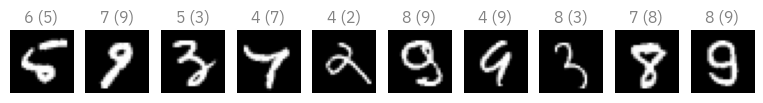

In [25]:
show_failures(nonlinear_model, test_dataloader)

## Recap

To train and validate a neural network model, you need:

- Data split into training/validation/test sets,
- A model with parameters to learn
- An appropriate loss function
- An optimizer (with tunable parameters such as learning rate, weight
  decay etc.) used to learn the parameters of the model.

## Homework

1.  Compare the quality of your model when using different:

- batch sizes
- learning rates
- activation functions

1.  Bonus: What is a learning rate scheduler?

If you have time, experiment with how to improve the model.

Note: training and validation data can be used to compare models, but
test data should be saved until the end as a final check of
generalization.

## Homework solution

Make the following changes to the cells with the comment “#For HW”

In [26]:
#####################To modify the batch size##########################
batch_size = 32 # 64, 128, 256, 512

# The dataloader makes our dataset iterable 
train_dataloader = torch.utils.data.DataLoader(training_data, batch_size=batch_size)
val_dataloader = torch.utils.data.DataLoader(validation_data, batch_size=batch_size)
##############################################################################


##########################To change the learning rate##########################
optimizer = torch.optim.SGD(nonlinear_model.parameters(), lr=0.01) #modify the value of lr
##############################################################################


##########################To change activation##########################
###### Go to https://pytorch.org/docs/main/nn.html#non-linear-activations-weighted-sum-nonlinearity for more activations ######
class NonlinearClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers_stack = nn.Sequential(
            nn.Linear(28*28, 50),
            nn.Sigmoid(), #nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(50, 50),
            nn.Tanh(), #nn.ReLU(),
           # nn.Dropout(0.2),
            nn.Linear(50, 50),
            nn.ReLU(),
           # nn.Dropout(0.2),
            nn.Linear(50, 10)
        )
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.layers_stack(x)

        return x
##############################################################################

Bonus question: A learning rate scheduler is an essential deep learning
technique used to dynamically adjust the learning rate during training.
This strategic can significantly impact the convergence speed and
overall performance of a neural network. See below on how to incorporate
it to your training.

In [27]:
nonlinear_model = NonlinearClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(nonlinear_model.parameters(), lr=0.1)

# Step learning rate scheduler: reduce by a factor of 0.1 every 2 epochs (only for illustrative purposes)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

In [28]:
%%time

epochs = 6
train_acc_all = []
val_acc_all = []
for j in range(epochs):
    train_one_epoch(train_dataloader, nonlinear_model, loss_fn, optimizer)
    #step the scheduler
    scheduler.step()

    # logger.info the current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    logger.info(f"Epoch {j+1}/{epochs}, Learning Rate: {current_lr}")

    # checking on the training loss and accuracy once per epoch
    acc, loss = evaluate(train_dataloader, nonlinear_model, loss_fn)
    train_acc_all.append(acc)
    logger.info(f"Epoch {j}: training loss: {loss}, accuracy: {acc}")

    # checking on the validation loss and accuracy once per epoch
    val_acc, val_loss = evaluate(val_dataloader, nonlinear_model, loss_fn)
    val_acc_all.append(val_acc)
    logger.info(f"Epoch {j}: val. loss: {val_loss}, val. accuracy: {val_acc}")